In [56]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys, os
# adding path to folder
sys.path.insert(0, '../tools/')

import matplotlib.pyplot as plt
plt.style.use('./cfg/my_custom_plot.mplstyle')

# use these lines on top of your matplotlib script
import matplotlib.ticker
class MyLocator(matplotlib.ticker.AutoMinorLocator):
    def __init__(self, n=4):
        super().__init__(n=n)
matplotlib.ticker.AutoMinorLocator = MyLocator        
 
# Now use matplotlib as usual.       
import matplotlib.pyplot as plt
plt.rcParams["xtick.minor.visible"] =  True
plt.rcParams["ytick.minor.visible"] =  True


from utils import load_dataset, load_keys, ParticleCode
# Load PDG Codes
pdg_tab = ParticleCode()

In [57]:
#plot_dir = './plots-gk/'
# Load datasets 
n_files = 995
location = "nersc"
df=load_dataset(n_files,'nersc')

Openning MiniRun 5 beta 2.a CAFs
Reading  995  files


877it [19:58,  1.37s/it]


In [59]:
anode_xs = np.array([-63.931, -3.069, 3.069, 63.931])
anode_ys = np.array([-19.8543, 103.8543]) - 42  # Subtract 42 from all y coordinates
anode_zs = np.array([-64.3163, -2.6837, 2.6837, 64.3163])

### Definition of the signal: 

We are interested in charged current muon neutrino interactions ocurring within the detector volume. We compare below the fraction of this type of processes expected from the simulation. Compare with the reconstruction information too.

## True Information

In [60]:


def signal_definition(pdg, ev_data, mode=None): 

        anode_xs = np.array([-63.931, -3.069, 3.069, 63.931])
        anode_ys = np.array([-19.8543, 103.8543]) - 42  # Subtract 42 from all y coordinates
        anode_zs = np.array([-64.3163, -2.6837, 2.6837, 64.3163])
        
        if (mode=='FV'):
                pass

        if(mode==None):
                numu_CC = ev_data['rec.mc.nu.pdg'][ 
                        (ev_data['rec.mc.nu.iscc']==1) &
                        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg)
                        ]
                return numu_CC
                
        if(mode=='DV'):
                mask_dv = (
                        (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
                        (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
                        (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) 
                        )
                #num interactions with Ar within the detector
                DV_nu = ev_data['rec.mc.nu.pdg'][(ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)& mask_dv]
                DV_numu_CC = ev_data['rec.mc.nu.pdg'][  
                        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) & 
                        (ev_data['rec.mc.nu.iscc']==1) &
                        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg) & mask_dv
                        ]
                
                return DV_nu, DV_numu_CC

numu_cc=[]
nu_dv= []
numu_cc_dv=[]

for ev in range(len(df)):
        ev_data= df.iloc[ev] 
        #grab info outside detector
        numucc =signal_definition(pdg_tab.numu,ev_data, mode =None)
        numu_cc.append(len(numucc))
        #grab info within detector
        dv, dv_ccnumu = signal_definition(pdg_tab.numu,ev_data, mode ='DV')
        nu_dv.append(len(dv))
        numu_cc_dv.append(len(dv_ccnumu))


nu_total = np.sum(df['rec.mc.nnu'])
numu_cc = np.sum(numu_cc)
nu_DV = np.sum(nu_dv)
numu_cc_DV = np.sum(numu_cc_dv)

npart=[nu_total, nu_DV, numu_cc_DV]
nfrac=[nu_total*100, nu_DV*100, numu_cc_DV*100]/nu_total
positions = [0,1,2]


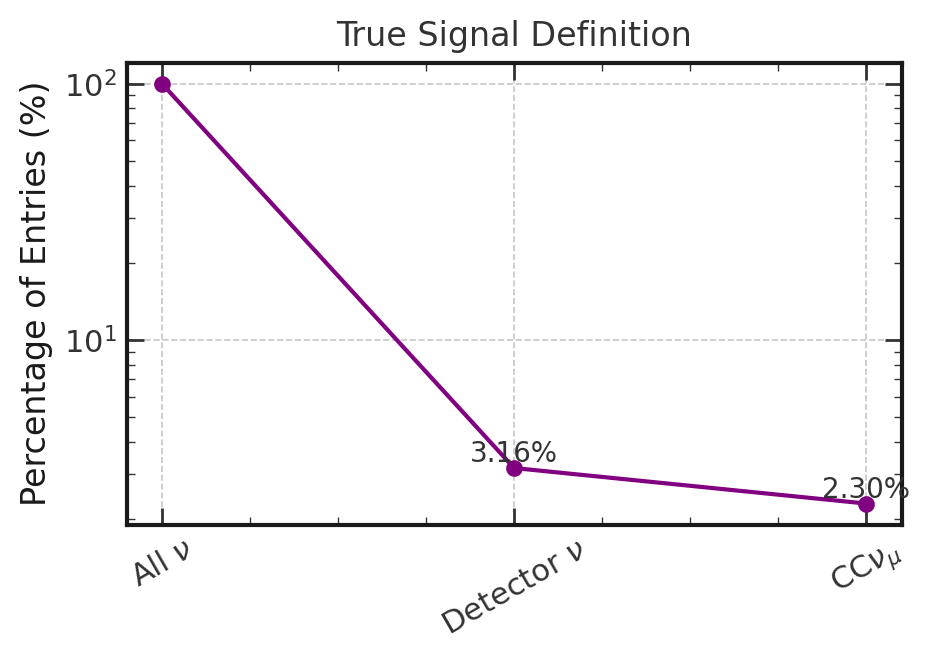

In [61]:

# Calculate the percentage with respect to nu_total
npart = np.array([nu_total, nu_DV, numu_cc_DV])
npercent = (npart / nu_total) * 100
positions = [0, 1, 2]

# Plotting the data as percentages
plt.plot(positions, npercent, marker='o', color='purple')
plt.xticks(positions, [r'All $\nu$', r'Detector $\nu$', r'CC$\nu_{\mu}$'], rotation=30)
# Adding the text annotations at each point
for i, value in enumerate(npercent):
    if i == 0:continue
    plt.text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom')
plt.yscale('log')
plt.title('True Signal Definition')
plt.ylabel('Percentage of Entries (%)')
plt.show()



In [62]:
E_nu_signal=[]
E_nu_dv = []
for ev in range(len(df)):           
    ev_data= df.iloc[ev]
    mask_signal = (
        (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
        (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
        (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) &
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) & 
        (ev_data['rec.mc.nu.iscc']==1) &
        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu))
    #print(ev_data['rec.mc.nu.pdg'][mask_signal])
    E_nu_signal.extend( ev_data['rec.mc.nu.E'][mask_signal])


In [63]:
E_neutron = []
E_proton_all = [] #save neutron energy
distances = [] #distance of the proton track to the vertex
track_lengths= [] #proton track lenght 
E_proton =[] #save proton energy
E_signal = []
E_nprim_all=[]
E_nu_neutron = [] #neutrino energy of the signal that has neutrons 
E_nu_n_p = [] #store neutrino energy of the signal that has n and p 
n_sig=0
n=0
n_dv =0
#n_munucc_total = 0 #num of neutrons in signal (not necessarily produced proton)
#n_prim_total=0 #num of prim neutrons in interaction
n_sec_total=0
for event in range(len(df)):

    ev_data= df.iloc[event]
    mask_dv = (
        (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
        (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
        (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) &
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)
    )
    
    mask_signal = (
        (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
        (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
        (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) &
        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) & 
        (ev_data['rec.mc.nu.iscc']==1) &
        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg_tab.numu)
    )
   
    n_vtx = len(ev_data['rec.mc.nu.E'])
    n += sum(ev_data['rec.mc.nu.nneutron'])
    n_dv += sum(ev_data['rec.mc.nu.nneutron'][mask_dv])
    n_sig += sum(ev_data['rec.mc.nu.nneutron'][mask_signal])
    #E_signal.extend(ev_data['rec.mc.nu.nneutron'][mask_signal]
    n_prim_total = len(ev_data['rec.mc.nu.prim.pdg'][ev_data['rec.mc.nu.prim.pdg'] == pdg_tab.neutron])
    #n_munucc_total += len(ev_data['rec.mc.nu.prim.pdg'][ev_data['rec.mc.nu.prim.pdg'] == pdg_tab.neutron])

    for vtx in range(n_vtx):  # Using n_vtx directly as the range
        
        #if vtx it is not in the signa, skip vtx
        if (ev_data['rec.mc.nu.E'][vtx] not in ev_data['rec.mc.nu.E'][mask_signal]):
            continue
        else:
            #now check for neutrons with proton daughter 
            tracked_neutron_ids = set()
            n_prim = ev_data['rec.mc.nu.prim..length'][vtx]
            n_sec = ev_data['rec.mc.nu.sec..length'][vtx]
            #get energy of all neutrons in interaction
            #E_nprim_all = ev_data['rec.mc.nu.prim.p.E'][(ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron )][vtx]
            if vtx == 0:
                n_pred_prim = 0
                n_pred_sec = 0
            else:
                n_pred_prim = np.sum(ev_data['rec.mc.nu.prim..length'][:vtx])
                n_pred_sec = np.sum(ev_data['rec.mc.nu.sec..length'][:vtx])
            #get energy of all neutrons: 
            included_vertex=False
            included_vertex_np = False
            for ip in range(n_pred_prim, n_pred_prim + n_prim):
                if (ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron):
                    E_nprim_all.append(ev_data['rec.mc.nu.prim.p.E'][ip]) 
                    
                    if included_vertex == False:
                        E_nu_neutron.extend(ev_data['rec.mc.nu.E'][mask_signal])
                        included_vertex= True
                    else: pass                      

            # iterate over secondary particles
            for isec in range(n_pred_sec, n_pred_sec + n_sec):
                # check if any of the secondary particles are protons
                if ev_data['rec.mc.nu.sec.pdg'][isec] == pdg_tab.proton:
                    # if proton, save the G4 ID of the parent
                    proton_parent_id = ev_data['rec.mc.nu.sec.parent'][isec]
                    # iterate over primary particles
                    E_proton_all.append(ev_data['rec.mc.nu.sec.p.E'][isec])
                    for ip in range(n_pred_prim, n_pred_prim + n_prim):
                        if (
                            ev_data['rec.mc.nu.prim.pdg'][ip] == pdg_tab.neutron and 
                            ev_data['rec.mc.nu.prim.G4ID'][ip] == proton_parent_id
                        ):
                            # This interaction has a proton produced by a neutron
                            if included_vertex_np == False:
                                E_nu_n_p.extend(ev_data['rec.mc.nu.E'][mask_signal])
                                included_vertex_np= True
                            else: pass 

                            if proton_parent_id not in tracked_neutron_ids:
                                #vtx_n_p[vtx] = True
                                #get energies and calculate distance to vertex
                                E_neutron.append(ev_data['rec.mc.nu.prim.p.E'][ip])
                                E_proton.append(ev_data['rec.mc.nu.sec.p.E'][isec])
                                tracked_neutron_ids.add(proton_parent_id)
                                #proton distance to vertex
                                distance_to_vertex= np.sqrt(
                                    (ev_data['rec.mc.nu.sec.start_pos.x'][isec] - ev_data['rec.mc.nu.vtx.x'][vtx] )**2 +
                                    (ev_data['rec.mc.nu.sec.start_pos.y'][isec]  - ev_data['rec.mc.nu.vtx.z'][vtx])**2 + 
                                    (ev_data['rec.mc.nu.sec.start_pos.z'][isec]  - ev_data['rec.mc.nu.vtx.y'][vtx])**2
                                    )
                                distances.append(distance_to_vertex)
                                #find track length 
                                track_length= np.sqrt(
                                    (ev_data['rec.mc.nu.sec.start_pos.x'][isec] - ev_data['rec.mc.nu.sec.end_pos.x'][isec])**2 +
                                    (ev_data['rec.mc.nu.sec.start_pos.y'][isec]  - ev_data['rec.mc.nu.sec.end_pos.y'][isec])**2 + 
                                    (ev_data['rec.mc.nu.sec.start_pos.z'][isec]  - ev_data['rec.mc.nu.sec.end_pos.z'][isec])**2
                                    )
                                track_lengths.append(track_length)


                            break  # Stop further checks for this proton
print(f'There are {n} primary neutrons, only {n_dv} happen within the detector')
print(f'There are {n_sig} primary neutrons from cc numu interactions')
print(f'There are {len(E_neutron)} primary neutrons from CC numu int that produced protons')
print(f'There are {len(E_nprim_all)} primary neutrons from CC numu ')
print(f'There are {len(E_nu_neutron)}, {len(E_nu_n_p)} ')
print(f'There are {len(E_proton)} sec protons from CC numu coming from neutrons')



There are 1488195 primary neutrons, only 53765 happen within the detector
There are 40360 primary neutrons from cc numu interactions
There are 3782 primary neutrons from CC numu int that produced protons
There are 40360 primary neutrons from CC numu 
There are 14651, 3746 
There are 3782 sec protons from CC numu coming from neutrons


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


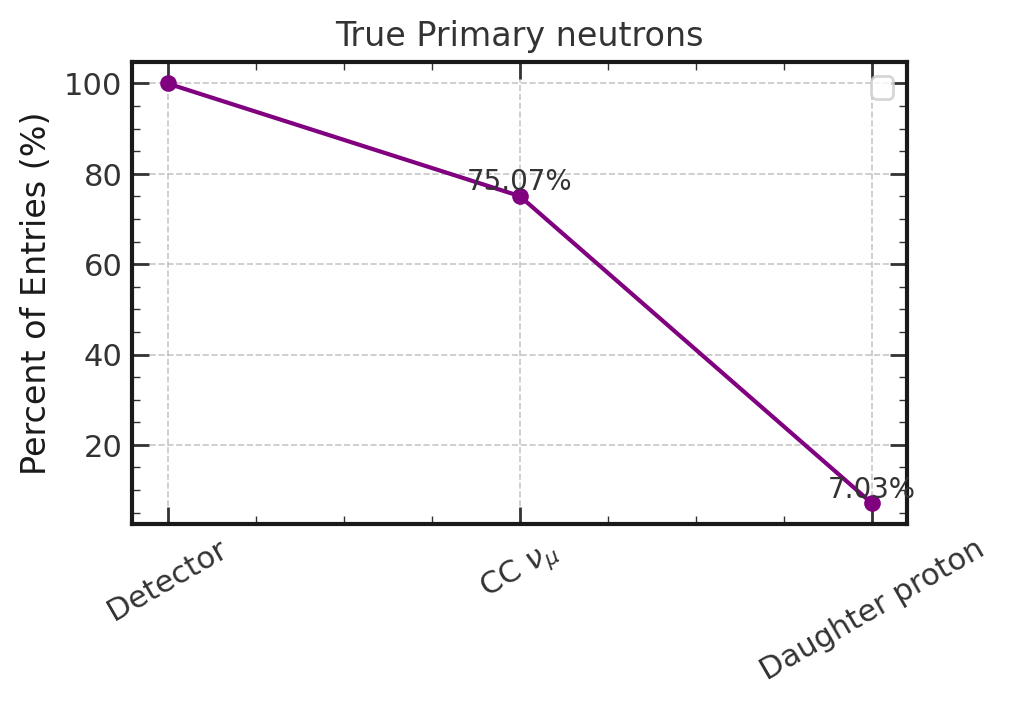

In [64]:
portions=[n_dv*100, n_sig*100, len(E_neutron)*100]/n_dv
positions = [0,1,2]
plt.plot(positions,portions,marker='o', color='purple')
plt.xticks(positions,[r'Detector',r'CC $\nu_{\mu}$', r'Daughter proton'],rotation=30)
#plt.yscale('log')
# Adding the text annotations at each point
for i, value in enumerate(portions):
    if i == 0:continue
    plt.text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom')
plt.title('True Primary neutrons')
plt.ylabel('Percent of Entries (%)')
plt.legend()
plt.show()

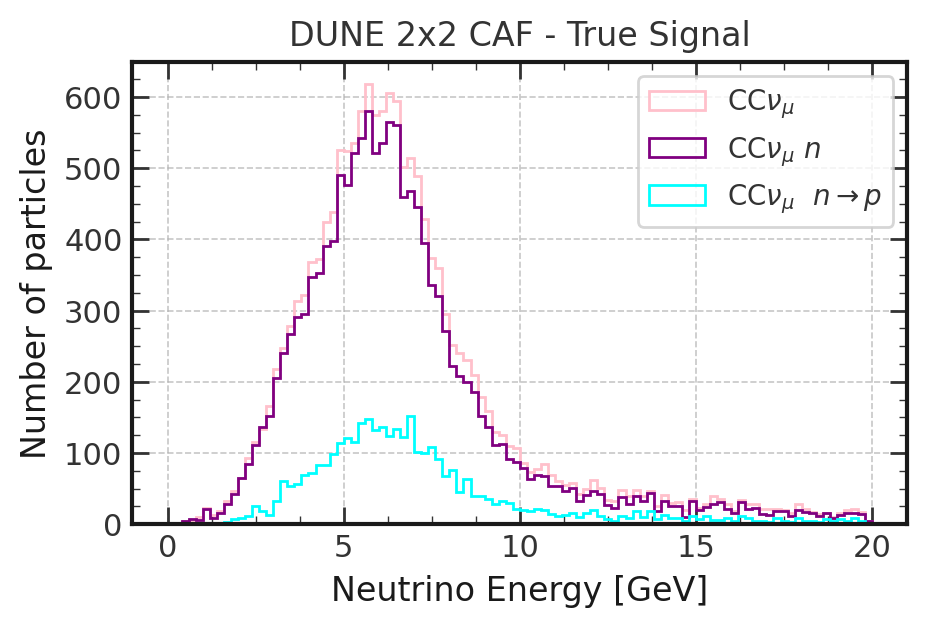

In [65]:
plt.hist(E_nu_signal,bins=100,histtype='step',range=(0,20), color='pink', label=r'CC$\nu_\mu$')
plt.hist(E_nu_neutron,bins=100,histtype='step',range=(0,20), color='purple', label=r'CC$\nu_\mu$ $n$')
plt.hist(E_nu_n_p,bins=100,histtype='step',range=(0,20), color='cyan', label=r'CC$\nu_\mu$  $n\rightarrow p$')
plt.ylabel('Number of particles')
plt.xlabel('Neutrino Energy [GeV]')
plt.title('DUNE 2x2 CAF - True Signal')
plt.legend()
#plt.yscale('log')
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


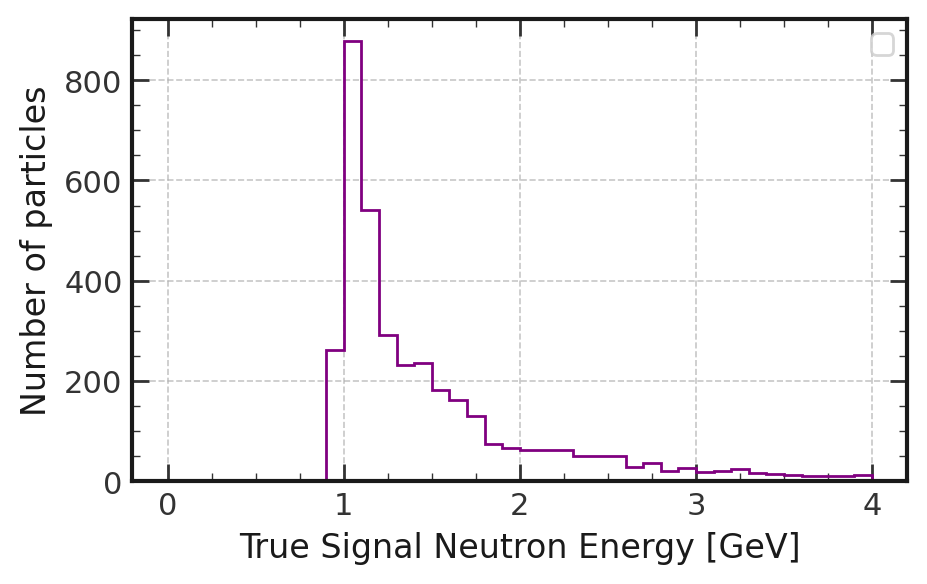

In [66]:
#plt.hist(parent_energies,bins=100,range=(0,400.),histtype='step',label='n')
plt.hist(E_neutron,bins=40,histtype='step', color='purple', range=(0,4))
#plt.hist(E_signal,bins=10,histtype='step', color='yellow')
#plt.title("Neutrons Truth")
plt.ylabel('Number of particles')
plt.xlabel('True Signal Neutron Energy [GeV]')
plt.legend()
#plt.yscale('log')
plt.show()

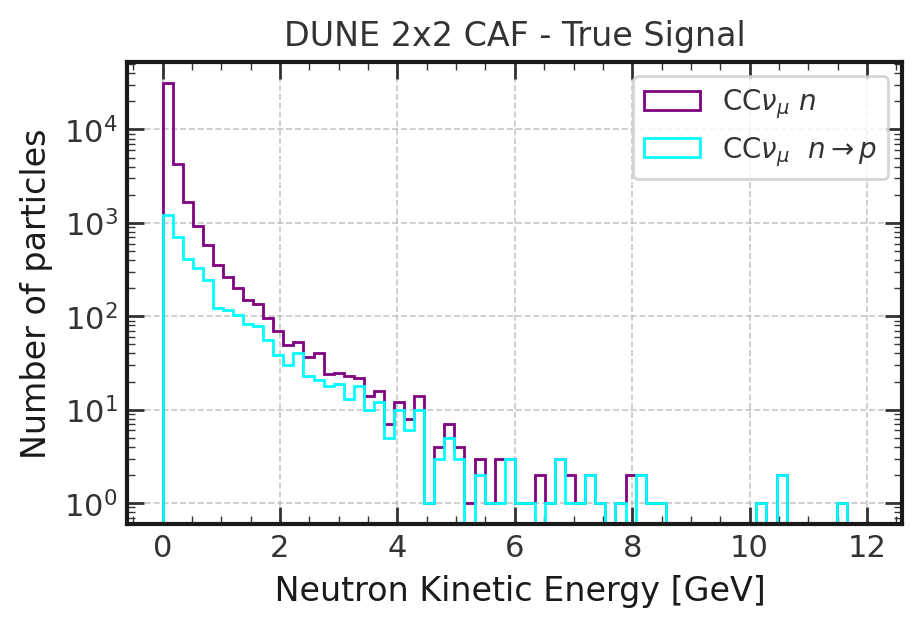

In [67]:
K_neutron= [x - pdg_tab.neutron_mass/1000 for x in E_neutron]
K_neutron_all =[x - pdg_tab.neutron_mass/1000 for x in E_nprim_all ]
plt.hist(K_neutron_all,bins=70,histtype='step', color='purple', range= [0,12], label=r'CC$\nu_\mu$ $n$')
plt.hist(K_neutron,bins=70,histtype='step', color='cyan',  range= [0,12],  label=r'CC$\nu_\mu$  $n\rightarrow p$')
#plt.hist(E_signal,bins=10,histtype='step', color='yellow')
#plt.title("Neutrons Truth")
plt.ylabel('Number of particles')
# Add title
plt.title('DUNE 2x2 CAF - True Signal')
plt.xlabel(' Neutron Kinetic Energy [GeV]')
plt.legend()
plt.yscale('log')
plt.show()

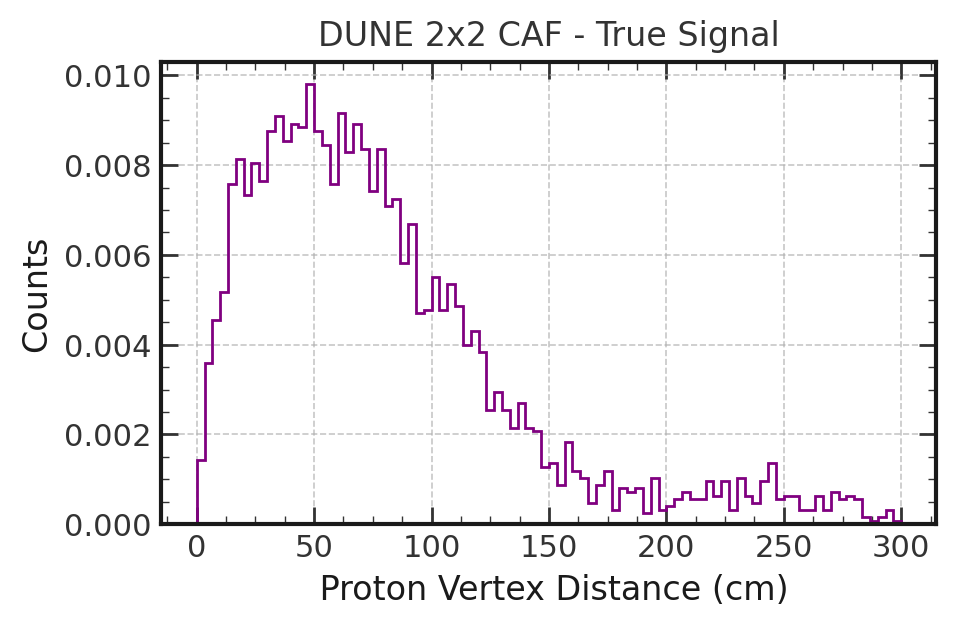

In [68]:
plt.hist(distances,bins=90,histtype='step',range=[0,300], color='purple', density=True,label=r'p')
# Add title
plt.title('DUNE 2x2 CAF - True Signal')
plt.xlabel(' Proton Vertex Distance (cm)')
plt.ylabel('Counts')
#plt.yscale('log')
plt.show()

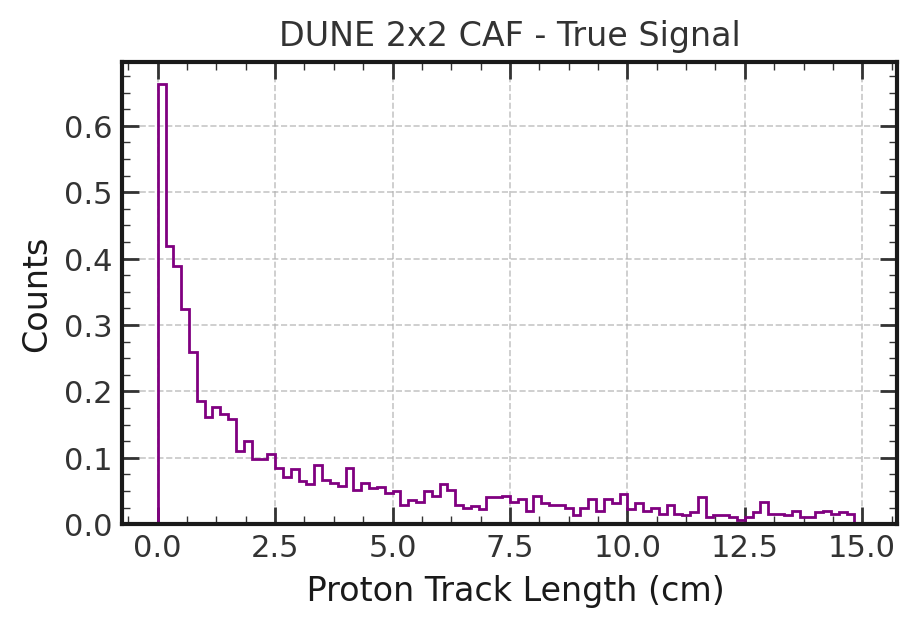

In [69]:
plt.hist(track_lengths,bins=90,histtype='step',range=[0,15], color='purple', density=True,label=r'p')
# Add title
plt.title('DUNE 2x2 CAF - True Signal')
plt.xlabel(' Proton Track Length (cm)')
plt.ylabel('Counts')
#plt.yscale('log')
plt.show()

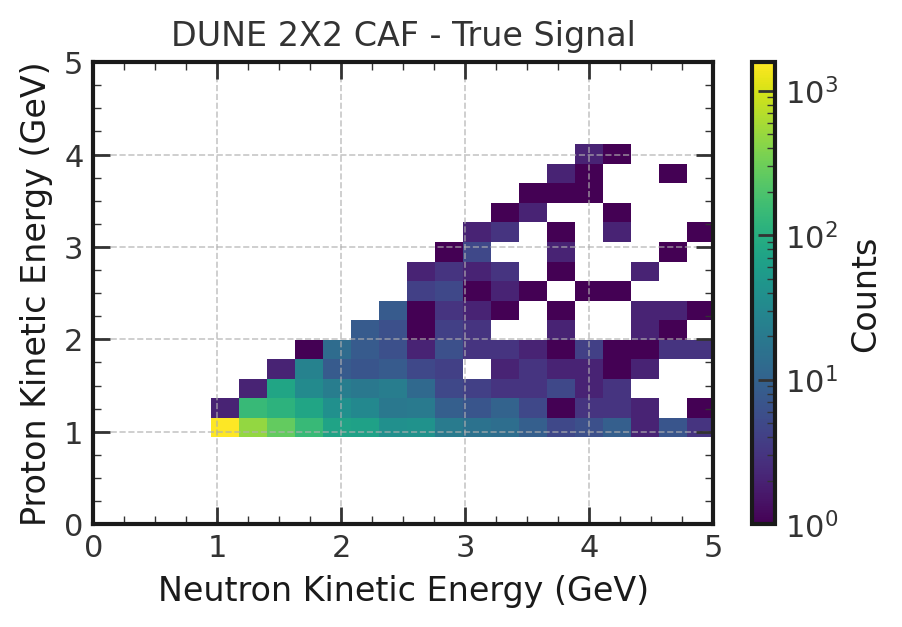

In [70]:
import matplotlib.colors as mcolors  # Importing the correct module for colors

K_neutron= [x - pdg_tab.neutron_mass/1000 for x in E_neutron]
K_proton =[x - pdg_tab.proton_mass/1000 for x in E_proton ]


plt.hist2d(E_neutron, E_proton, bins=90, norm=mcolors.LogNorm(), cmap='viridis')
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.colorbar(label='Counts')
plt.xlabel('Neutron Kinetic Energy (GeV)')
plt.ylabel('Proton Kinetic Energy (GeV)')
plt.title('DUNE 2X2 CAF - True Signal')
plt.show()


## Reconstruction Information

In [71]:
def signal_definition(pdg, ev_data, mode=None): 

        anode_xs = np.array([-63.931, -3.069, 3.069, 63.931])
        anode_ys = np.array([-19.8543, 103.8543]) - 42  # Subtract 42 from all y coordinates
        anode_zs = np.array([-64.3163, -2.6837, 2.6837, 64.3163])
        
        if (mode=='FV'):
                pass

        if(mode==None):
                numu_CC = ev_data['rec.mc.nu.pdg'][ 
                        (ev_data['rec.mc.nu.iscc']==1) &
                        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg)
                        ]
                return numu_CC
                
        if(mode=='DV'):
                mask_dv = (
                        (ev_data['rec.mc.nu.vtx.x'] >= anode_xs[0]) & (ev_data['rec.mc.nu.vtx.x'] <= anode_xs[3]) &
                        (ev_data['rec.mc.nu.vtx.y'] >= anode_ys[0]) & (ev_data['rec.mc.nu.vtx.y'] <= anode_ys[1]) &
                        (ev_data['rec.mc.nu.vtx.z'] >= anode_zs[0]) & (ev_data['rec.mc.nu.vtx.z'] <= anode_zs[3]) 
                        )
                #num interactions with Ar within the detector
                DV_nu = ev_data['rec.mc.nu.pdg'][(ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon)& mask_dv]
                DV_numu_CC = ev_data['rec.mc.nu.pdg'][  
                        (ev_data['rec.mc.nu.targetPDG']== pdg_tab.argon) & 
                        (ev_data['rec.mc.nu.iscc']==1) &
                        (np.abs(ev_data['rec.mc.nu.pdg']) == pdg) & mask_dv
                        ]
                
                return DV_nu, DV_numu_CC

numu_cc=[]
nu_dv= []
numu_cc_dv=[]

for ev in range(len(df)):
        ev_data= df.iloc[ev] 
        #grab info outside detector
        numucc =signal_definition(pdg_tab.numu,ev_data, mode =None)
        numu_cc.append(len(numucc))
        #grab info within detector
        dv, dv_ccnumu = signal_definition(pdg_tab.numu,ev_data, mode ='DV')
        nu_dv.append(len(dv))
        numu_cc_dv.append(len(dv_ccnumu))


nu_total = np.sum(df['rec.mc.nnu'])
numu_cc = np.sum(numucc)
nu_DV = np.sum(nu_dv)
numu_cc_DV = np.sum(numu_cc_dv)

In [72]:
n_numucc_dv = 0 #num of numucc interactions in dv 
n_dv_reco=[] #num of interaction in detector volume

for ev in range(len(df)):
    ev_data=df.iloc[ev]
    n_ixn = ev_data['rec.common.ixn.dlp..length']
    n_part_ixn = ev_data['rec.common.ixn.dlp.part.dlp..length']
    n_part_ixn_pdg = ev_data['rec.common.ixn.dlp.part.dlp.pdg']
    # Mask for detector volume interactions
    mask_dv = ((ev_data['rec.common.ixn.dlp.vtx.x'] >= anode_xs[0]) & 
            (ev_data['rec.common.ixn.dlp.vtx.x'] <= anode_xs[3]) &
            (ev_data['rec.common.ixn.dlp.vtx.y'] >= anode_ys[0]) & 
            (ev_data['rec.common.ixn.dlp.vtx.y'] <= anode_ys[1]) &
            (ev_data['rec.common.ixn.dlp.vtx.z'] >= anode_zs[0]) & 
            (ev_data['rec.common.ixn.dlp.vtx.z'] <= anode_zs[3]))

    DV_nu = ev_data['rec.common.ixn.dlp.part.dlp..length'][mask_dv]
    n_dv_reco.append(len(DV_nu))
    # Apply the mask to get interactions within the detector volume
    n_part_ixn_dv = n_part_ixn[mask_dv]
    # Initialize a boolean array to store True/False values, same size as n_part_ixn_pdg
    masked_pdgs = np.zeros_like(n_part_ixn_pdg, dtype=bool)
    # Iterates over the interactions of the event
    n_pred = 0  
    
    for vtx in range(len(n_part_ixn)):
        # Check if the current vertex is within the detector volume
        if mask_dv[vtx]:
            # Check if there's a muon in the current interaction
            is_numuCC = np.any(n_part_ixn_pdg[n_pred: n_pred + n_part_ixn[vtx]] == pdg_tab.muon)
            if is_numuCC: 
                n_numucc_dv += 1
            masked_pdgs[n_pred: n_pred + n_part_ixn[vtx]] = is_numuCC
        n_pred += n_part_ixn[vtx]

n_dv_total_reco=np.sum(n_dv_reco)
print(f'interactions dv: {n_dv_total_reco}, {n_numucc_dv}')


interactions dv: 154740, 43597


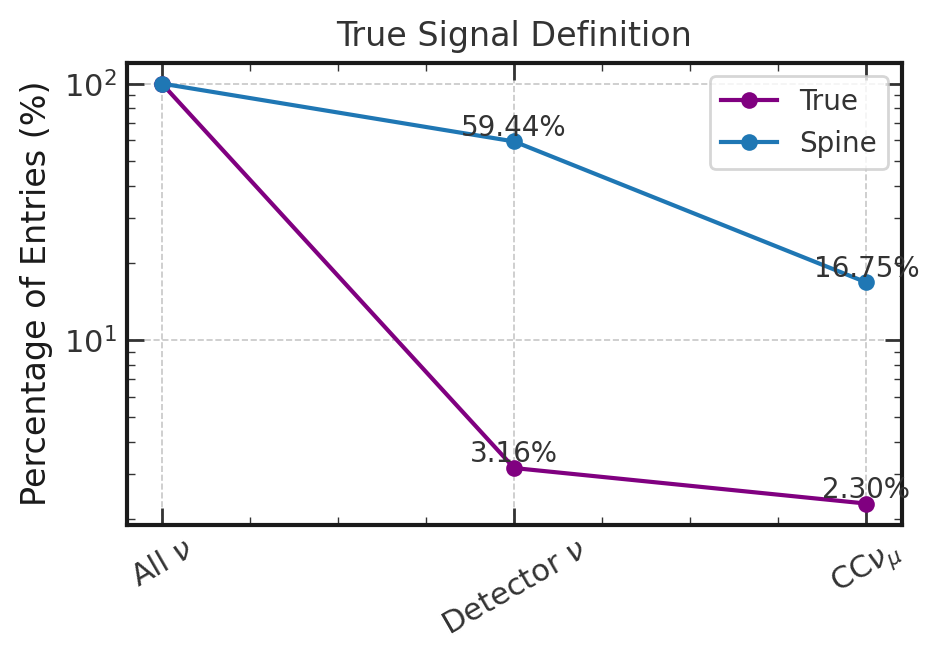

In [73]:
# Calculate the percentage with respect to nu_total
npart = np.array([nu_total, nu_DV, numu_cc_DV])
npercent = (npart / nu_total) * 100
#reco
n_total_ixn=np.sum(df['rec.common.ixn.dlp..length'])
portions=[n_total_ixn*100, n_dv_total_reco*100, n_numucc_dv*100]/n_total_ixn
positions = [0, 1, 2]

plt.plot(positions, npercent, marker='o', color='purple', label = 'True')
plt.plot(positions,portions,marker='o',label='Spine')
plt.xticks(positions, [r'All $\nu$', r'Detector $\nu$', r'CC$\nu_{\mu}$'], rotation=30)
# Adding the text annotations at each point
for i, value in enumerate(npercent):
    if i == 0:continue
    plt.text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom')
for i, value in enumerate(portions):
    if i == 0:continue
    plt.text(positions[i], value, f'{value:.2f}%', ha='center', va='bottom')
plt.yscale('log')
plt.title('True Signal Definition')
plt.ylabel('Percentage of Entries (%)')
plt.legend()
plt.show()

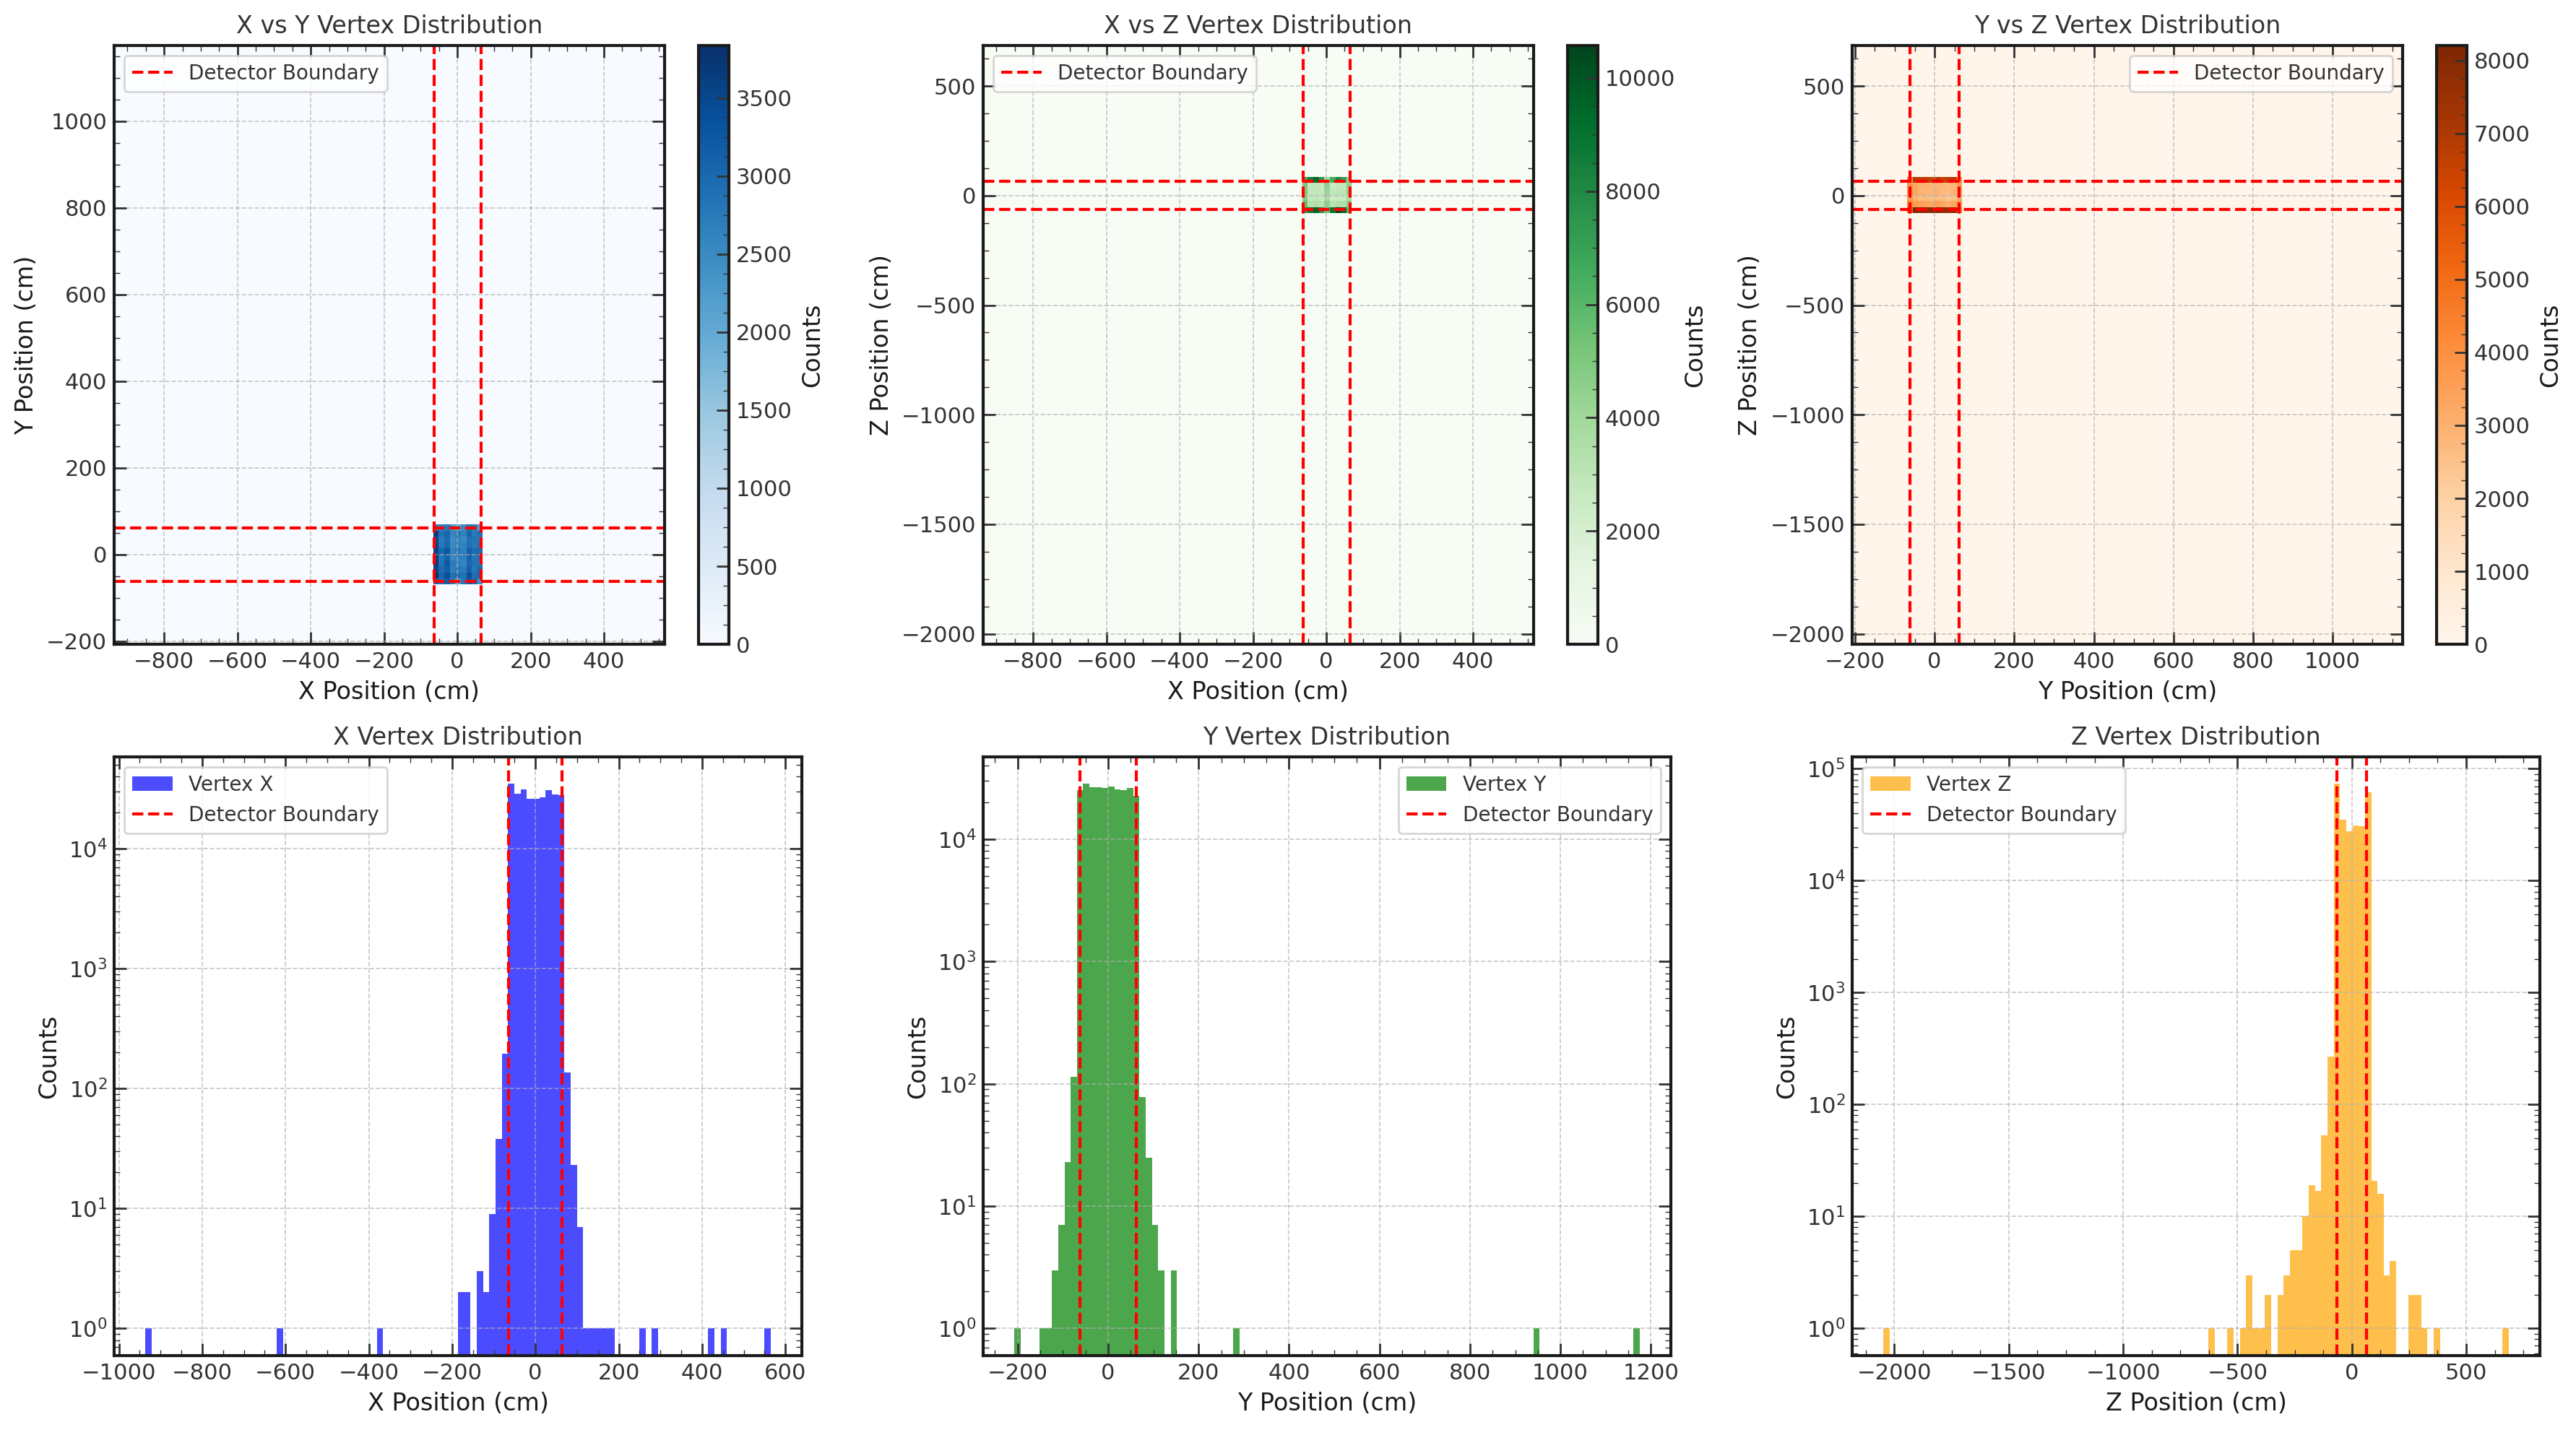

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming anode_xs, anode_ys, anode_zs are already defined

# Create lists to store the vertex positions
vertices_x = []
vertices_y = []
vertices_z = []

for ev in range(len(df)):
    ev_data = df.iloc[ev]
    # Collect vertex positions for each event
    vertices_x.extend(ev_data['rec.common.ixn.dlp.vtx.x'])
    vertices_y.extend(ev_data['rec.common.ixn.dlp.vtx.y'])
    vertices_z.extend(ev_data['rec.common.ixn.dlp.vtx.z'])

# Plot the distributions
plt.figure(figsize=(18, 10))

# Plot X vs Y 2D distribution
plt.subplot(2, 3, 1)
plt.hist2d(vertices_x, vertices_y, bins=100, cmap='Blues')
plt.axvline(anode_xs[0], color='red', linestyle='--', label='Detector Boundary')
plt.axvline(anode_xs[3], color='red', linestyle='--')
plt.axhline(anode_ys[0], color='red', linestyle='--')
plt.axhline(anode_ys[1], color='red', linestyle='--')
plt.title('X vs Y Vertex Distribution')
plt.xlabel('X Position (cm)')
plt.ylabel('Y Position (cm)')
plt.colorbar(label='Counts')
#plt.yscale('log')
plt.legend()

# Plot X vs Z 2D distribution
plt.subplot(2, 3, 2)
plt.hist2d(vertices_x, vertices_z, bins=100, cmap='Greens')
plt.axvline(anode_xs[0], color='red', linestyle='--', label='Detector Boundary')
plt.axvline(anode_xs[3], color='red', linestyle='--')
plt.axhline(anode_zs[0], color='red', linestyle='--')
plt.axhline(anode_zs[3], color='red', linestyle='--')
plt.title('X vs Z Vertex Distribution')
plt.xlabel('X Position (cm)')
plt.ylabel('Z Position (cm)')
plt.colorbar(label='Counts')
#plt.yscale('log')
plt.legend()

# Plot Y vs Z 2D distribution
plt.subplot(2, 3, 3)
plt.hist2d(vertices_y, vertices_z, bins=100, cmap='Oranges')
plt.axvline(anode_ys[0], color='red', linestyle='--', label='Detector Boundary')
plt.axvline(anode_ys[1], color='red', linestyle='--')
plt.axhline(anode_zs[0], color='red', linestyle='--')
plt.axhline(anode_zs[3], color='red', linestyle='--')
plt.title('Y vs Z Vertex Distribution')
plt.xlabel('Y Position (cm)')
plt.ylabel('Z Position (cm)')
plt.colorbar(label='Counts')
#plt.yscale('log')
plt.legend()

# Plot 1D X vertex distribution
plt.subplot(2, 3, 4)
plt.hist(vertices_x, bins=100, alpha=0.7, color='blue', label='Vertex X')
plt.axvline(anode_xs[0], color='red', linestyle='--', label='Detector Boundary')
plt.axvline(anode_xs[3], color='red', linestyle='--')
plt.title('X Vertex Distribution')
plt.xlabel('X Position (cm)')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

# Plot 1D Y vertex distribution
plt.subplot(2, 3, 5)
plt.hist(vertices_y, bins=100, alpha=0.7, color='green', label='Vertex Y')
plt.axvline(anode_ys[0], color='red', linestyle='--', label='Detector Boundary')
plt.axvline(anode_ys[1], color='red', linestyle='--')
plt.title('Y Vertex Distribution')
plt.xlabel('Y Position (cm)')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

# Plot 1D Z vertex distribution
plt.subplot(2, 3, 6)
plt.hist(vertices_z, bins=100, alpha=0.7, color='orange', label='Vertex Z')
plt.axvline(anode_zs[0], color='red', linestyle='--', label='Detector Boundary')
plt.axvline(anode_zs[3], color='red', linestyle='--')
plt.title('Z Vertex Distribution')
plt.xlabel('Z Position (cm)')
plt.ylabel('Counts')
plt.yscale('log')
plt.legend()

plt.tight_layout()
plt.show()


In [75]:
count_protons = 0
count_neutrons = 0

for ev in range(len(df)):
    ev_data = df.iloc[ev]

    ixn_index = len(ev_data['rec.common.ixn.dlp.id'])
    for ixn in range(0, ixn_index):
        #print(ixn_index)
        n_ixn = len(ev_data['rec.common.ixn.dlp.id'])
        n_particles = ev_data['rec.common.ixn.dlp.part.dlp..length'][ixn]
        if(ixn==0):
            n_pre = 0
        else: 
            n_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp..length'][:ixn]) 
        # Scan over particles associated to this ixn 
        for ip in range(n_pre,n_pre + n_particles):
            #print(ip)
            # Check if particle is primary 
            is_primary = ev_data['rec.common.ixn.dlp.part.dlp.primary'][ip]
            reco_pdg = ev_data['rec.common.ixn.dlp.part.dlp.pdg'][ip]

            if (is_primary==False and reco_pdg==pdg_tab.proton):
                # find best match 
                truth_length = ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][ip]
                truth_pre = np.sum(ev_data['rec.common.ixn.dlp.part.dlp.truth..length'][:ip])
                max_overlap = 0
                best_match_idx = 0
                best_match_type = 0
                for tp in range(truth_pre,truth_pre+truth_length):
                    temp_overlap = ev_data['rec.common.ixn.dlp.part.dlp.truthOverlap'][tp]
                    temp_tp_match = ev_data['rec.common.ixn.dlp.part.dlp.truth.part'][tp]
                    temp_tp_type = ev_data['rec.common.ixn.dlp.part.dlp.truth.type'][tp] # 1 prim and 3 second
                    if(temp_overlap>max_overlap):
                        max_overlap=temp_overlap
                        best_match_idx=temp_tp_match
                        best_match_type=temp_tp_type
                if(best_match_type==3):
                    #print('sec')
                    best_match_pdg = ev_data['rec.mc.nu.sec.pdg'][best_match_idx]
                    if (best_match_pdg == pdg_tab.proton): 
                        count_protons += 1
                
print(count_protons)


58567
